## Capstone Project 1 — Customer Churn Prediction

Customer churn is one of the most important business problems faced by subscription-based companies such as telecom providers. A customer who leaves does not only represent the loss of an existing source of revenue, but also the loss of future business and the potential cost of acquiring a replacement customer.

The objective of this project is therefore to build an end-to-end Customer Churn Prediction system capable of moving from raw customer data to actionable business decisions.

### Business Problem

The central business question addressed in this project was:

>Can customer data be used to identify customers who are likely to churn, understand the factors associated with their churn, and prioritize them for appropriate retention actions?

A traditional business approach would react only after a customer has already left. A predictive approach attempts to identify risk before churn occurs, giving the company an opportunity to intervene.
The project therefore aimed to transform customer data into a practical retention-support system.

### Predictive Modelling

A Logistic Regression model was used as the primary predictive model because it is well suited to binary classification and, importantly, provides an interpretable baseline.

The model learns the relationship between customer characteristics and the probability of churn.

Rather than producing only a binary result such as:

>Churn = Yes

the model can generate a probability such as:

>Churn Probability = 0.82

This probability becomes particularly valuable from a business perspective because customers can be prioritized according to their estimated risk.

A Random Forest classifier was also considered as a more flexible nonlinear model. Comparing the models allows model selection to be based on observed performance rather than assuming that one algorithm is automatically superior.

## DATA UNDERSTANDING

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../../Datasets_MLmodels/Chosen_Datasets/telecom_churn.csv")

In [2]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [3]:
df.shape

(243553, 14)

In [4]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [6]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [7]:
df.describe(include="object")

,telecom_partner,gender,state,city,date_of_registration
count,243553,243553,243553,243553,243553
unique,4,2,28,6,1220
top,Reliance Jio,M,Uttarakhand,Chennai,2020-01-01
freq,61123,145977,8856,40749,200


## DATA QUALITY

In [8]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [9]:
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [12]:
df["churn"].value_counts()

churn
0    194726
1     48827
Name: count, dtype: int64

In [13]:
df["churn"].value_counts(normalize=True) * 100

churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64

## EXPLORATORY DATA ANALYSIS

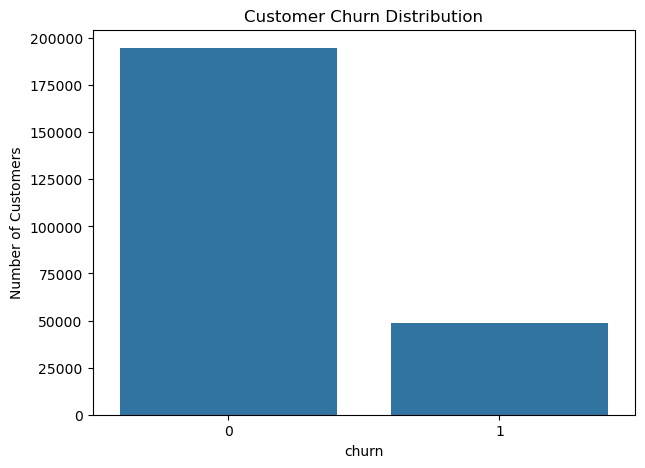

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("churn")
plt.ylabel("Number of Customers")

plt.show()

In [15]:
def churn_by_category(column, figsize=(8,5)):
    plt.figure(figsize=figsize)

    sns.countplot(
        data=df,
        x=column,
        hue="churn"
    )
    
    plt.title(f"Churn Distribution by {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [16]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

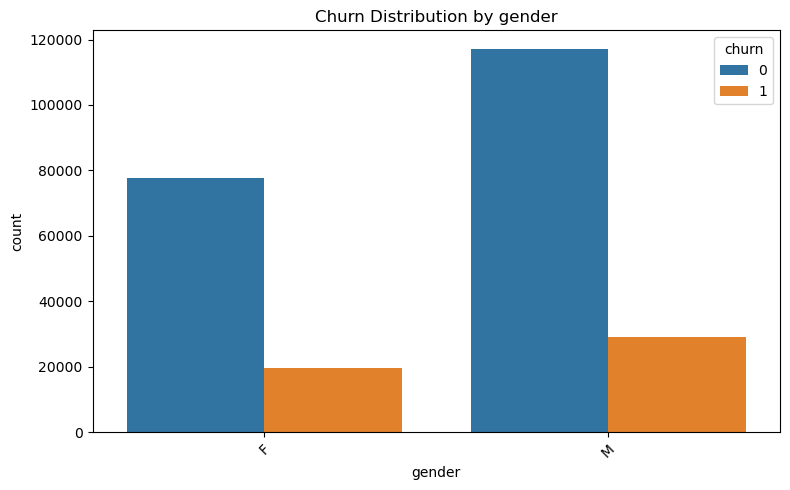

In [17]:
churn_by_category("gender")

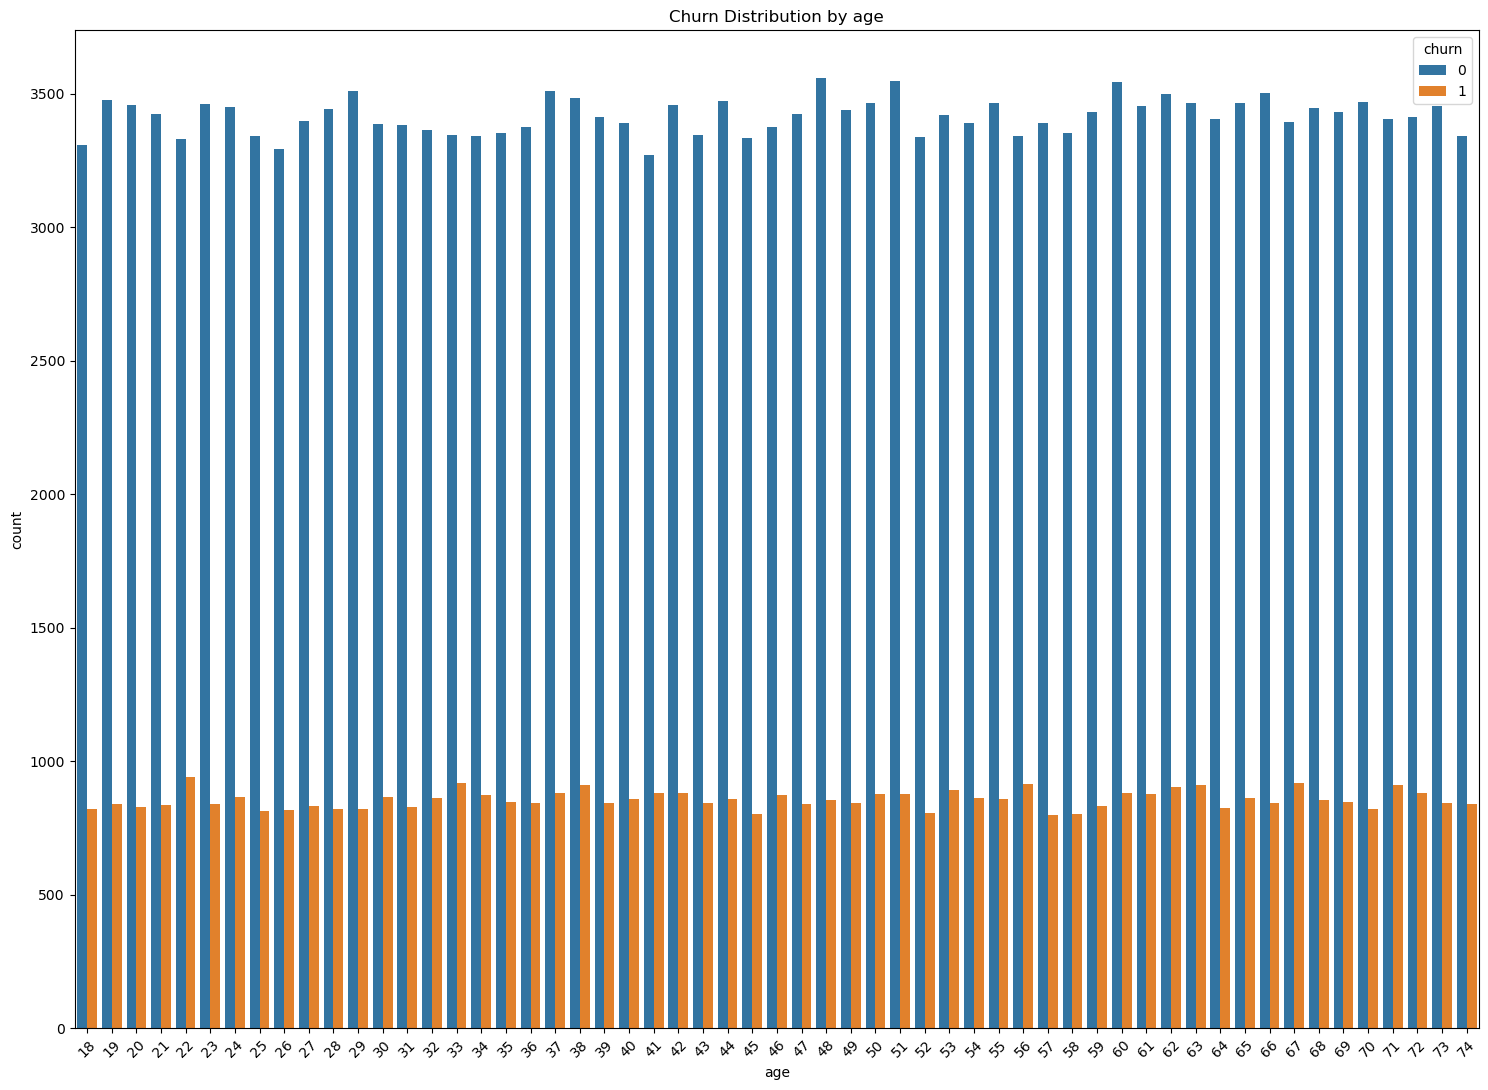

In [18]:
churn_by_category("age", figsize=(15,11))

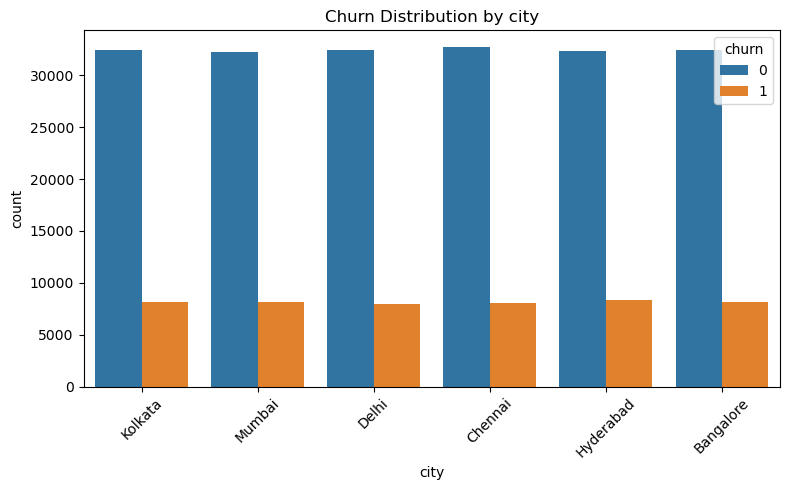

In [19]:
churn_by_category("city")

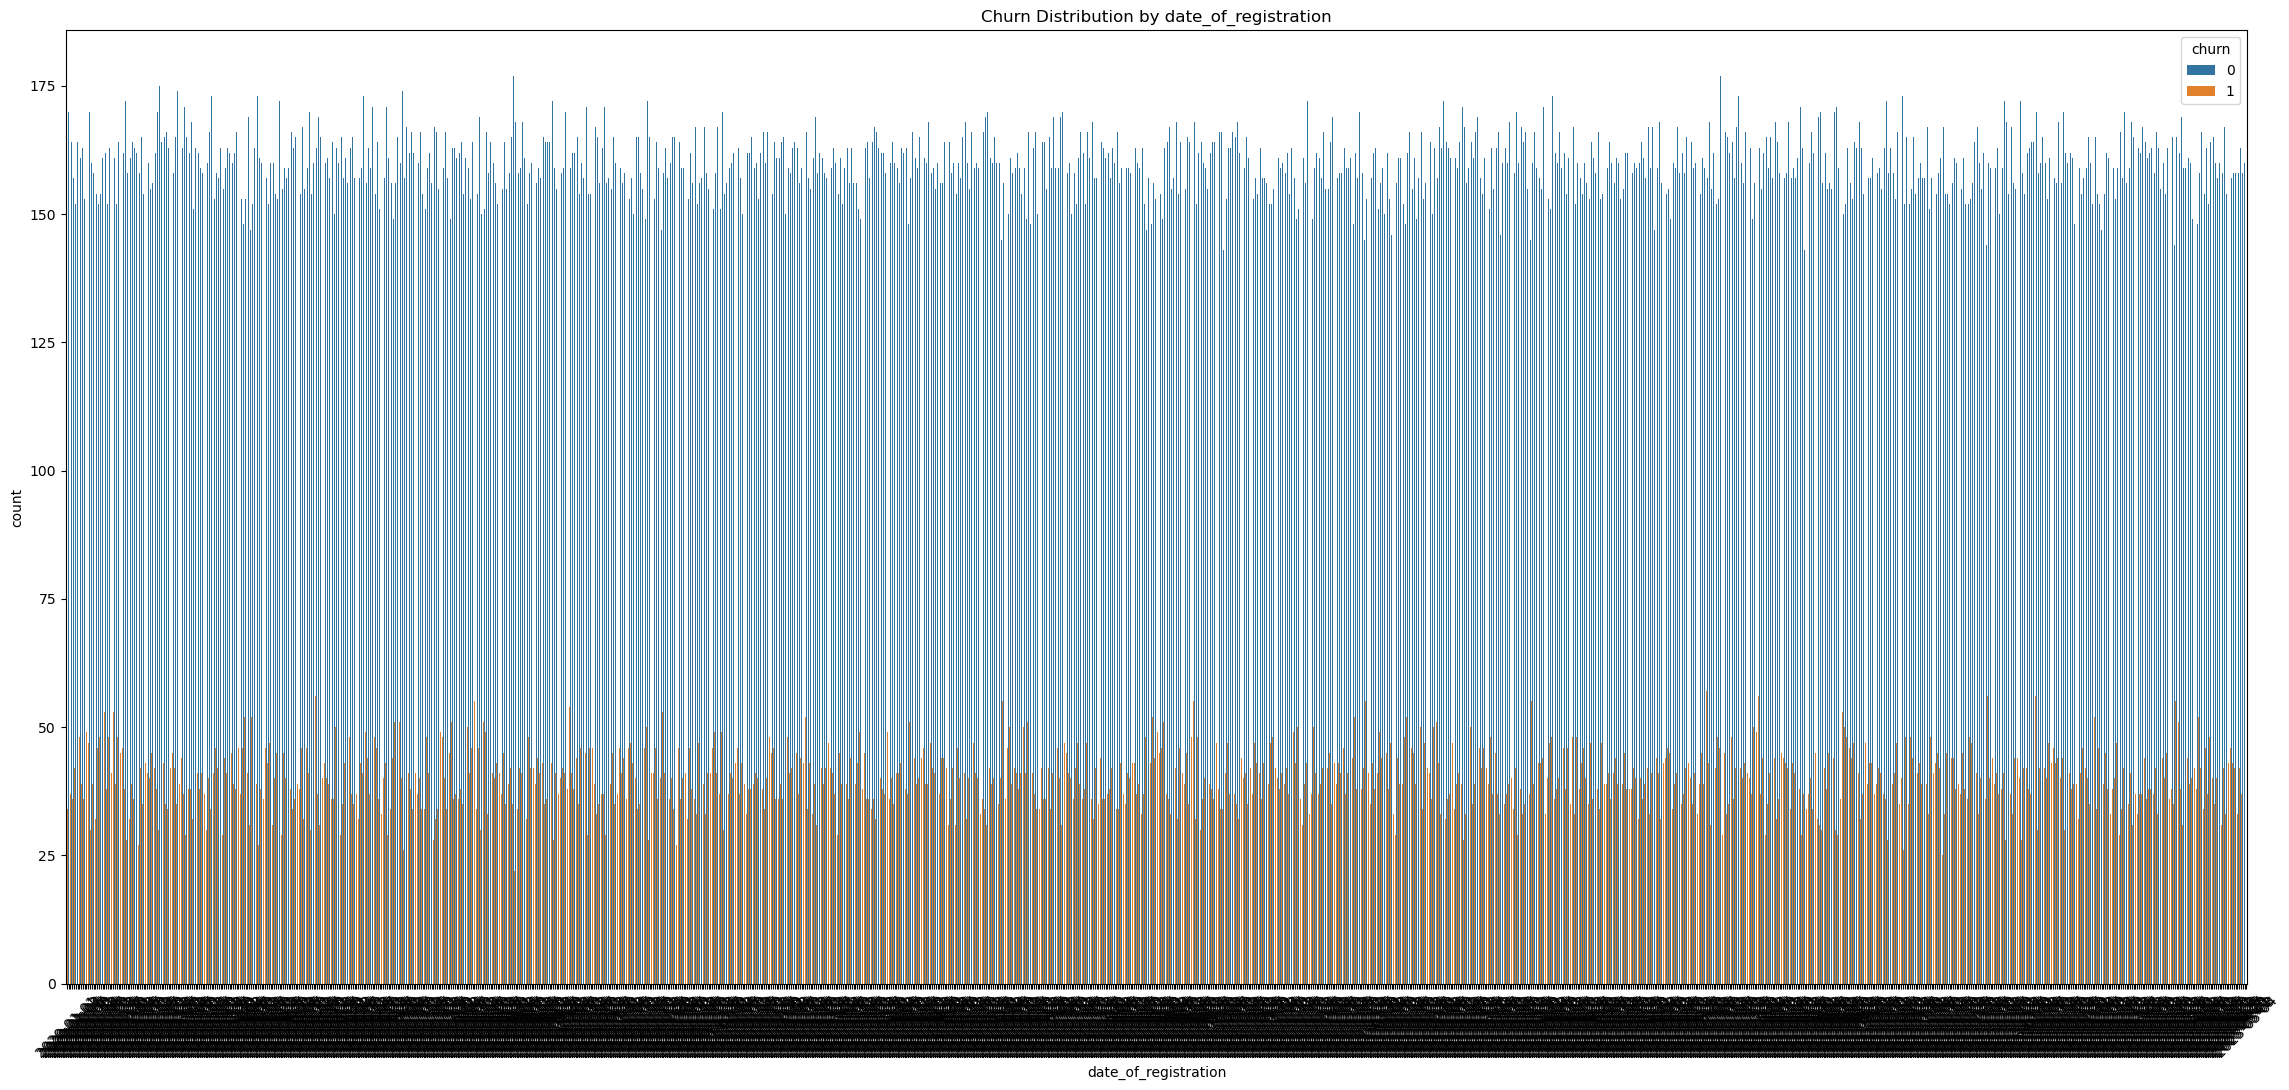

In [20]:
churn_by_category("date_of_registration", figsize=(23,11))

In [21]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [22]:
churn_rate = (
    df.groupby("state")["churn"]
      .mean()
      .sort_values(ascending=False)
)
churn_rate

state
Jharkhand            0.211194
Karnataka            0.207123
Mizoram              0.206468
Uttarakhand          0.204155
Himachal Pradesh     0.204100
Madhya Pradesh       0.203811
Assam                0.202995
Odisha               0.202479
Nagaland             0.202289
Rajasthan            0.202171
Manipur              0.201133
Telangana            0.201059
Uttar Pradesh        0.200755
Sikkim               0.200714
Haryana              0.200343
Gujarat              0.200232
Goa                  0.199563
Tamil Nadu           0.199358
Maharashtra          0.199093
Arunachal Pradesh    0.198927
Andhra Pradesh       0.198520
Meghalaya            0.197490
Bihar                0.196340
Kerala               0.195301
Tripura              0.194804
Chhattisgarh         0.194307
Punjab               0.194251
West Bengal          0.194004
Name: churn, dtype: float64

In [23]:
churn_rate = (
    df.groupby("telecom_partner")["churn"]
      .mean()
      .sort_values(ascending=False)
)
churn_rate

telecom_partner
Airtel          0.203661
Reliance Jio    0.200154
Vodafone        0.199484
BSNL            0.198607
Name: churn, dtype: float64

In [24]:
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['customer_id', 'age', 'pincode', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

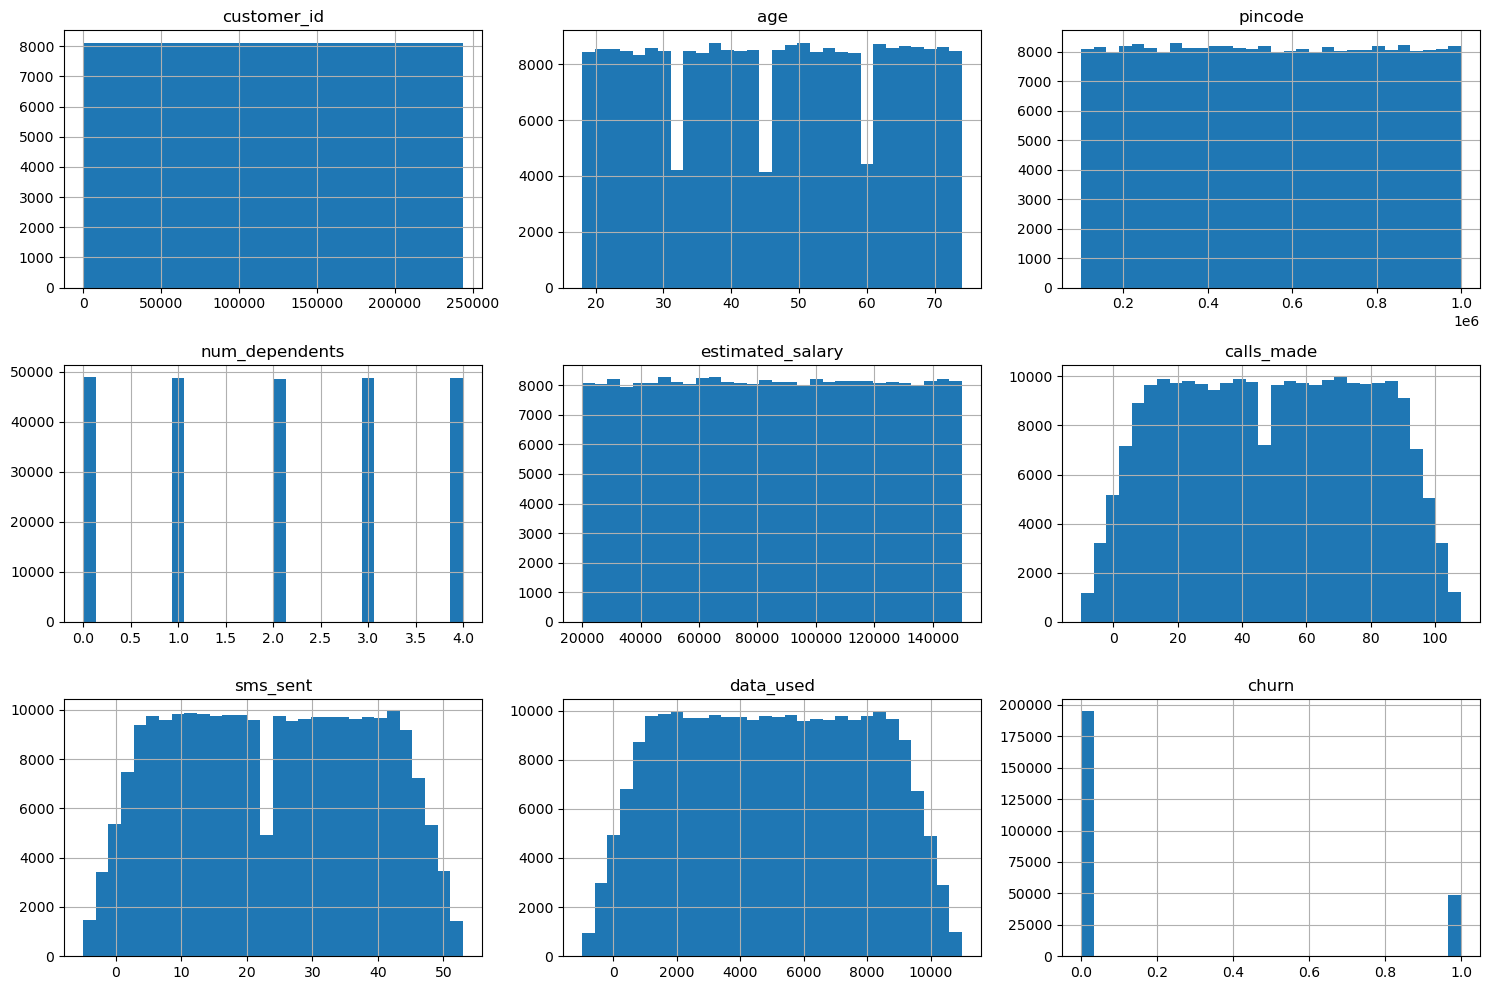

In [25]:
df[numeric_columns].hist(
    figsize=(15, 10),
    bins=30
)
plt.tight_layout()
plt.show()

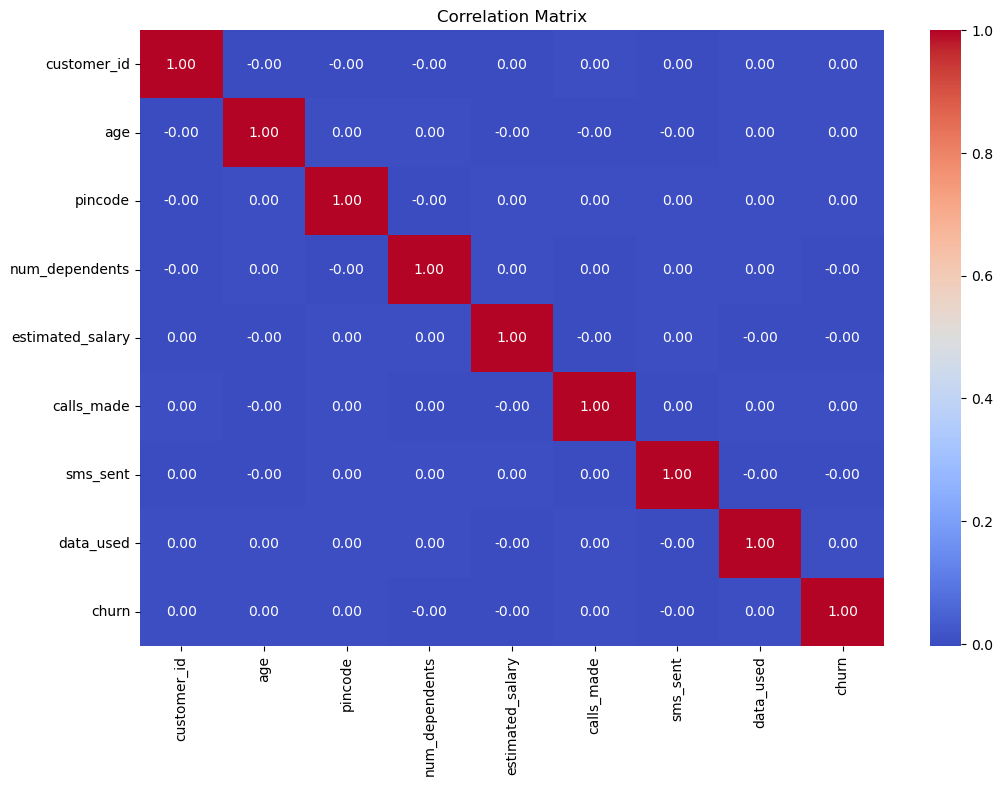

In [26]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")

plt.show()

## DATA PREPARATION

In [27]:
X = df.drop("churn", axis=1)
y = df["churn"]

In [28]:
categorical_columns = X.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['telecom_partner', 'gender', 'state', 'city', 'date_of_registration'], dtype='object')

In [29]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [30]:
X.shape

(243553, 1263)

In [31]:
X.isnull().sum().sum()

np.int64(0)

## ML Feasibility

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## MODEL

In [34]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred = model.predict(X_test_scaled)

In [36]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

In [37]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7995319332388988


In [38]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.0


In [39]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.0


In [40]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.0


In [41]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.505745900115772


In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



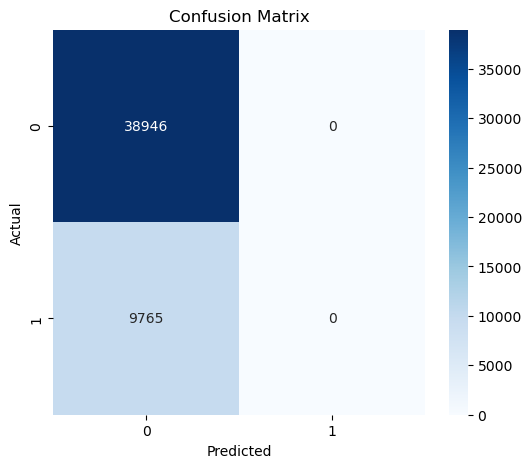

In [43]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Churn Risk Analysis

In [44]:
risk_df = X_test.copy()

risk_df["Actual_Churn"] = y_test.values
risk_df["Churn_Probability"] = y_probability

In [45]:
def risk_category(probability):
    if probability >= 0.75:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

In [46]:
risk_df["Risk_Level"] = (risk_df["Churn_Probability"].apply(risk_category))
risk_df["Risk_Level"].value_counts()

Risk_Level
Low Risk    48711
Name: count, dtype: int64

In [47]:
high_risk_customers = risk_df[risk_df["Risk_Level"] == "High Risk"]
high_risk_customers.head()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,telecom_partner_BSNL,telecom_partner_Reliance Jio,...,date_of_registration_2023-04-28,date_of_registration_2023-04-29,date_of_registration_2023-04-30,date_of_registration_2023-05-01,date_of_registration_2023-05-02,date_of_registration_2023-05-03,date_of_registration_2023-05-04,Actual_Churn,Churn_Probability,Risk_Level


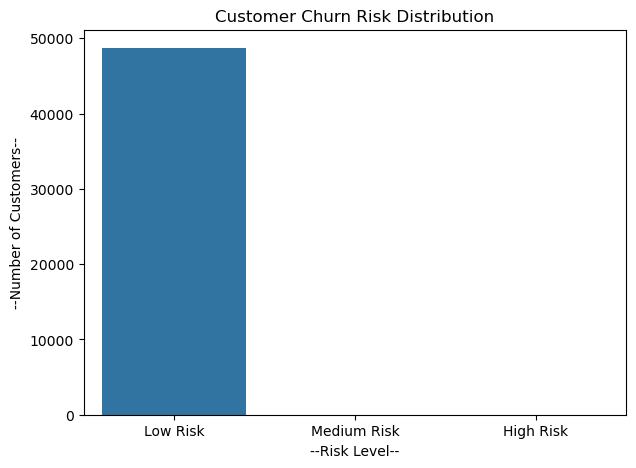

In [48]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=risk_df,
    x="Risk_Level",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("--Risk Level--")
plt.ylabel("--Number of Customers--")

plt.show()

## Model Interpretation
Accuracy = X%.

Customers classified as High Risk should receive the highest retention priority.

Logistic Regression also allows us to investigate which features contribute positively or negatively to the churn prediction.

In [49]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
293,date_of_registration_2020-09-07,-0.027542,0.027542
95,date_of_registration_2020-02-22,-0.019145,0.019145
968,date_of_registration_2022-07-14,-0.018151,0.018151
315,date_of_registration_2020-09-29,-0.017081,0.017081
1092,date_of_registration_2022-11-15,-0.016960,0.016960
1127,date_of_registration_2022-12-20,-0.016032,0.016032
960,date_of_registration_2022-07-06,0.015813,0.015813
94,date_of_registration_2020-02-21,-0.015223,0.015223
1061,date_of_registration_2022-10-15,-0.015133,0.015133
1015,date_of_registration_2022-08-30,0.015031,0.015031


Positive coefficients indicate increasing influence toward the churn class, while negative coefficients indicate movement toward the non-churn class, holding the other model features constant.

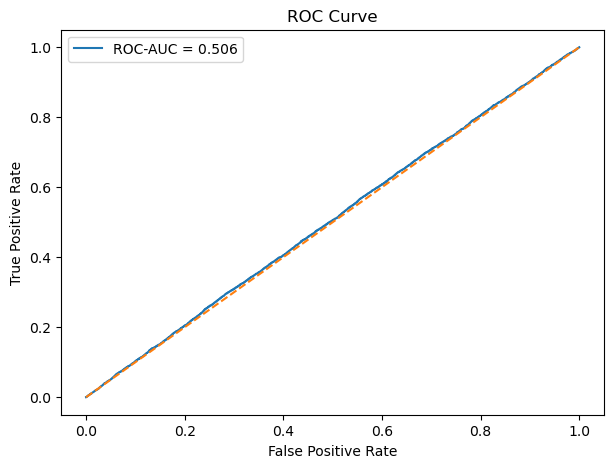

In [50]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)